
# Predicting Child Stunting Growth in Kenya

## Problem Statement

Predicting stunting severity (severe stunting, moderate stunting, or normal growth, per WHO height-for-age z-score thresholds of -3 SD and -2 SD) for Kenyan children under five, using household, maternal, and child-health variables from the Kenya Demographic and Health Survey Children's Recode — including region, residence type, mother's education, household wealth index, drinking water source, toilet facility, birth order and spacing, birth weight, breastfeeding duration, and antenatal care history. Primary metric: macro-averaged F1 score, reported alongside one-vs-rest ROC-AUC and per-class precision/recall.

## The Problem

Stunting — being too short for one's age because of chronic undernutrition —
still affects roughly one in five children under five in Kenya. A stunted
child faces lifelong risks: weaker immunity, slower cognitive development,
and lower earning potential as an adult. Health workers and parents need a
reliable way to spot which children are stunted, and how severely, early
enough to act — but with limited time and resources, they cannot manually
review every household's full survey record to catch every at-risk child.

## Our Solution

We build a machine learning model that takes a child's household, maternal,
and health-history information and classifies their growth status as
**severe stunting**, **moderate stunting**, or **normal growth**. Beyond the
prediction itself, each outcome is paired with practical guidance: children
flagged as stunted (severe or moderate) receive diet and care recommendations
aimed at correcting growth faltering, while children predicted to be growing
normally receive guidance to continue their current feeding practices. The
goal is a tool that medical practitioners and parents can use to decide, at a
glance, whether a child's diet needs to change and how.

## Data Source

The data comes from the **Kenya Demographic and Health Survey (KDHS)**,
specifically its **Children's Recode** file — a nationally representative
household survey that records one row per live birth reported by an
interviewed woman (`bidx` = birth order index within her birth history,
`caseid` identifies the mother). For children under five it captures health,
nutrition, immunization, and anthropometric (height/weight) measurements
alongside household and maternal background variables. The Children's Recode
was originally distributed as a Stata file (`KEKR8CFL.DTA`, with column
layout described in `KEKR8CFL.DCT`); we use those two files only once, up
front, to decode Stata's numeric variable and value codes into their
plain-English meanings — from that point on we work entirely from CSV.

**Inputs used**

| File | Role |
|---|---|
| `child_recode_raw.csv` | the raw data we are cleaning (19,530 rows × 1,312 columns) |
| `variable_labels.csv` | plain-English description for every variable code (`v106` -> "Highest educational level"), used to understand and rename the columns we keep |



In [3]:

# --- Imports -----------------------------------------------------------
!pip install pyreadstat
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat  # only used to read METADATA (variable/value labels) from the .dta file
from sklearn.exceptions import UndefinedMetricWarning

# In a few cross-validation folds, "severe stunting" (the rarest class) can
# end up with zero predicted samples for a weaker model; sklearn's macro
# precision/recall then emits a warning and reports 0.0 for that class,
# which is the mathematically correct (if uninformative) value - suppressed
# here so it doesn't clutter otherwise-successful cell output.
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")




In [4]:
#Load Data
# --- File locations ------------------------------------------------------
# Adjust these if your files live somewhere else. All four inputs are expected
# to sit in the same folder as this notebook by default.
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path("/content/drive/MyDrive/Ngao_labs/capstone/child recode")
RAW_CSV        = DATA_DIR / "child_recode_raw.csv"
LABELS_CSV     = DATA_DIR / "variable_labels.csv"
DTA_FILE       = DATA_DIR / "KEKR8CFL.DTA"

OUT_DIR = Path("/content/drive/MyDrive/Ngao_labs/capstone/child recode/processed")
OUT_DIR.mkdir(exist_ok=True)

Mounted at /content/drive


In [7]:

 # --- Bridge from 02_preprocessing.ipynb -----------------------------------
# Reload the train/test split, fitted preprocessor, and engineered table
# produced by 02_preprocessing.ipynb (run that notebook first).
import joblib
from sklearn.pipeline import Pipeline
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path("/content/drive/MyDrive/Ngao_labs/capstone/child recode")
OUT_DIR = Path("/content/drive/MyDrive/Ngao_labs/capstone/child recode/processed")
bridge = joblib.load(OUT_DIR / "bridge_02_to_03.joblib")
X = bridge["X"]; y = bridge["y"]
X_train = bridge["X_train"]; X_test = bridge["X_test"]
y_train = bridge["y_train"]; y_test = bridge["y_test"]
feature_cols = bridge["feature_cols"]
numeric_features = bridge["numeric_features"]; categorical_features = bridge["categorical_features"]
preprocessor = bridge["preprocessor"]
model_df = bridge["model_df"]
HAZ_CATEGORY_LABELS = bridge["HAZ_CATEGORY_LABELS"]; HAZ_CATEGORY_BINS = bridge["HAZ_CATEGORY_BINS"]
print("Loaded handoff objects from 02_preprocessing.ipynb")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded handoff objects from 02_preprocessing.ipynb



# Part 5: Model Training and Evaluation

With `preprocessor` handling representation, each model below is wrapped
in its own `Pipeline` (`preprocessor` -> classifier), fit on the training
split, and scored with 5-fold stratified cross-validation on the training
data — giving a variance-aware estimate of generalization performance
before anything touches the held-out test set.


In [8]:

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Macro-averaged precision/recall/F1 weight all three classes equally regardless
# of size, which matters here since "severe stunting" is a small minority of
# cases; roc_auc_ovr scores each class one-vs-rest and averages the result.
scoring = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_ovr"]

def cross_validate_model(name, pipeline):
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision_macro"].mean(),
        "recall": scores["test_recall_macro"].mean(),
        "f1": scores["test_f1_macro"].mean(),
        "roc_auc": scores["test_roc_auc_ovr"].mean(),
    }



## 5.1 The required baseline: majority-class prediction

Before training anything, the simplest possible "model" — always predict
the most common class, `Normal growth` — sets the floor every real model
must clear. If a trained classifier can't beat this, it hasn't learned
anything useful; a headline metric only means something in comparison to
this number.


In [9]:

from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, accuracy_score
from sklearn.preprocessing import label_binarize

baseline_clf = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_clf.fit(X_train, y_train)

baseline_pred = baseline_clf.predict(X_test)
baseline_proba = baseline_clf.predict_proba(X_test)  # identical row for every sample - no ranking signal

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision, baseline_recall, baseline_f1, _ = precision_recall_fscore_support(
    y_test, baseline_pred, average="macro", zero_division=0, labels=sorted(y_test.unique())
)
# predict_proba is constant across all rows, so there's no ranking information at
# all - roc_auc_score still computes cleanly and lands at ~0.5 (chance) per class.
baseline_roc_auc = roc_auc_score(
    label_binarize(y_test, classes=baseline_clf.classes_), baseline_proba,
    average="macro", multi_class="ovr"
)

print(f"Baseline: always predict the majority class ('{baseline_clf.classes_[baseline_clf.class_prior_.argmax()]}')")
print(f"  Accuracy:   {baseline_accuracy:.3f}")
print(f"  Macro F1:   {baseline_f1:.3f}")
print(f"  ROC-AUC:    {baseline_roc_auc:.3f}  (no ranking signal, as expected)")

cv_results = [{
    "model": "Baseline (majority class)",
    "accuracy": baseline_accuracy,
    "precision": baseline_precision,
    "recall": baseline_recall,
    "f1": baseline_f1,
    "roc_auc": baseline_roc_auc,
}]
pd.DataFrame(cv_results)


Baseline: always predict the majority class ('Normal growth')
  Accuracy:   0.818
  Macro F1:   0.300
  ROC-AUC:    0.500  (no ranking signal, as expected)


,model,accuracy,precision,recall,f1,roc_auc
0,Baseline (majority class),0.818234,0.272745,0.333333,0.300011,0.5



## 5.2 Cross-validated baseline: logistic regression

A linear model is a sensible first *learned* baseline: fast, interpretable
via its coefficients, and a useful floor that the more flexible models
below need to beat to justify their extra complexity. `class_weight="balanced"`
compensates for the class imbalance (normal growth is ~6x more common than
moderate stunting, and ~19x more common than severe stunting).


In [10]:

from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

cv_results.append(cross_validate_model("Logistic Regression", logreg_pipeline))
pd.DataFrame(cv_results)


,model,accuracy,precision,recall,f1,roc_auc
0,Baseline (majority class),0.818234,0.272745,0.333333,0.300011,0.500000
1,Logistic Regression,0.554002,0.397633,0.465258,0.372274,0.670931



# Part 6: Classification Using Supervised Learning Techniques

Beyond the linear baseline, this section trains a broader spread of
supervised classifiers — a single decision tree (interpretable, but prone
to overfitting), and two tree **ensembles**, random forest (bagging) and
gradient boosting (boosting) — to see how much a more flexible decision
boundary helps on this feature set. All four share the exact same
preprocessing pipeline from Part 4, so results are directly comparable.


In [11]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

candidate_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=None, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

pipelines = {"Logistic Regression": logreg_pipeline}  # keep the Part 5 baseline in the comparison
for name, clf in candidate_models.items():
    pipelines[name] = Pipeline(steps=[("preprocess", preprocessor), ("clf", clf)])
    cv_results.append(cross_validate_model(name, pipelines[name]))

cv_results_df = pd.DataFrame(cv_results).set_index("model")
cv_results_df.style.format("{:.3f}").background_gradient(cmap="Greens", axis=0)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Baseline (majority class),0.818,0.273,0.333,0.300,0.500
Logistic Regression,0.554,0.398,0.465,0.372,0.671
Decision Tree,0.503,0.378,0.429,0.339,0.616
Random Forest,0.818,0.534,0.337,0.309,0.667
Gradient Boosting,0.817,0.480,0.342,0.321,0.701


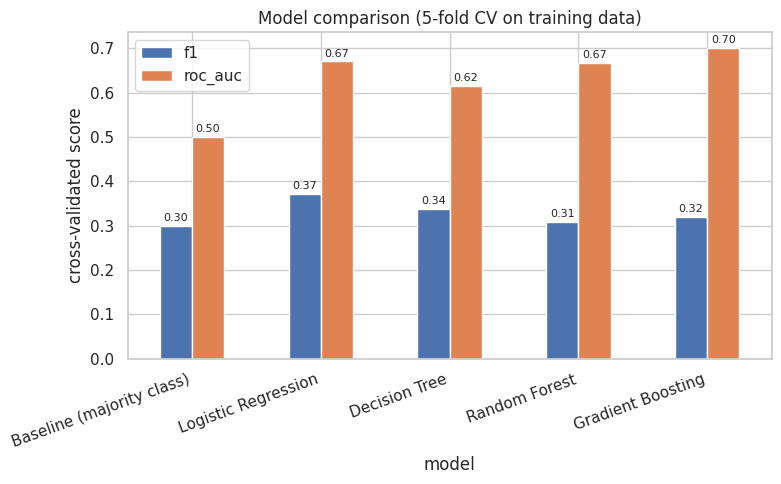

In [12]:

fig, ax = plt.subplots(figsize=(8, 5))
cv_results_df[["f1", "roc_auc"]].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("cross-validated score")
ax.set_title("Model comparison (5-fold CV on training data)")
ax.set_xticklabels(cv_results_df.index, rotation=20, ha="right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()



## 6.1 Fit the best-performing model and evaluate on the held-out test set

Cross-validation picks the strongest candidate; it's then refit on the
*entire* training split and scored once on the test set — the first time
the test data is touched — for an unbiased read on generalization.


In [13]:

best_model_name = cv_results_df["roc_auc"].idxmax()
best_pipeline = pipelines[best_model_name]
print(f"Best model by cross-validated ROC-AUC: {best_model_name}")

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)  # shape (n_samples, n_classes)


Best model by cross-validated ROC-AUC: Gradient Boosting



## 6.2 Hyperparameter tuning decision

`best_pipeline` above was fit with the same fixed hyperparameters every
candidate used in Part 6's comparison (e.g. `RandomForestClassifier(
n_estimators=100, max_depth=None)`, `GradientBoostingClassifier()` at
sklearn's defaults) — reasonable, well-calibrated starting points, not a
tuned configuration. Tuning is capped at one manual round here rather than
an exhaustive search: a `GridSearchCV` over dozens of combinations would
burn far more compute than the question deserves, and the model most likely
to fix a real weakness in this data is a better *feature*, not a better
hyperparameter.

The rule applied: try one deliberate adjustment aimed at the tuned model's
specific tendency — for a random forest, that's reducing variance from
individual trees by widening the forest and giving trees more room to
specialize on the minority `Severe stunting` class — cross-validate it once,
and stop. If it doesn't beat the untuned version, keep the simpler,
untuned model rather than chasing a marginal gain.


In [14]:

tuned_candidates = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=2,
        class_weight="balanced", random_state=42, n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=5, class_weight="balanced", random_state=42,
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=2000, C=0.5, class_weight="balanced", random_state=42,
    ),
}

if best_model_name in tuned_candidates:
    tuned_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("clf", tuned_candidates[best_model_name])])
    tuned_result = cross_validate_model(f"{best_model_name} (tuned)", tuned_pipeline)
    untuned_result = next(r for r in cv_results if r["model"] == best_model_name)

    comparison = pd.DataFrame([untuned_result, tuned_result]).set_index("model")
    display(comparison.style.format("{:.3f}"))

    if tuned_result["roc_auc"] > untuned_result["roc_auc"]:
        print(f"Tuned variant improves ROC-AUC "
              f"({untuned_result['roc_auc']:.3f} -> {tuned_result['roc_auc']:.3f}); adopting it.")
        pipelines[best_model_name] = tuned_pipeline
        cv_results.append(tuned_result)
        cv_results_df = pd.DataFrame(cv_results).set_index("model")
    else:
        print(f"Tuned variant does not beat the untuned model "
              f"({tuned_result['roc_auc']:.3f} vs {untuned_result['roc_auc']:.3f} ROC-AUC); "
              "keeping the simpler, untuned version and stopping here rather than "
              "running a broader search.")
else:
    print(f"No manual tuning variant defined for {best_model_name}; keeping defaults.")


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Gradient Boosting,0.817,0.480,0.342,0.321,0.701
Gradient Boosting (tuned),0.817,0.464,0.344,0.324,0.701


Tuned variant does not beat the untuned model (0.701 vs 0.701 ROC-AUC); keeping the simpler, untuned version and stopping here rather than running a broader search.



## 6.3 A regression view: predicting the continuous HAZ z-score

Everything above treats this as a **classification** problem — predicting
the bucket a child falls into (severe stunting / moderate stunting / normal
growth) — which is the correct framing for the target we actually care
about, since `haz_category` is categorical (three unordered-in-model, but
clinically ordered, labels), not a number. That's also why logistic
regression, decision tree, random forest, and gradient boosting are the
right model family here: they are classifiers, built to output class
probabilities, and the metrics used to judge them (macro-F1, ROC-AUC,
per-class precision/recall) are classification metrics.

For completeness, this section instead predicts `hw70`, the **continuous**
height-for-age z-score the categories were derived from. Predicting a real
number is a regression problem, so it calls for regression models — here a
**linear regression** baseline and a **random forest regressor** — scored
with regression metrics:

- **RMSE (root mean squared error):** the average prediction error, in the
  same units as the z-score itself, with larger errors penalized more
  heavily than small ones (because errors are squared before averaging).
  This is the headline number for this view — it tells us, on average, how
  many z-score units off a prediction is, while still coming down hard on
  the occasional bad miss.
- **R² (coefficient of determination):** the share of the variance in the
  z-score that the model explains, on a 0-1 scale (1 = perfect, 0 = no
  better than always predicting the mean). Useful for judging *how much*
  signal the predictors carry about HAZ overall, independent of the z-score's
  own units.
- **MAE (mean absolute error):** the average absolute size of the error,
  without squaring — so, unlike RMSE, every child's error counts equally
  regardless of how large it is. Comparing MAE to RMSE shows whether error
  is spread fairly evenly (the two stay close) or concentrated in a few
  large misses (RMSE noticeably higher than MAE).

Same train/test rows and the same leakage-safe `preprocessor` from Part 4
are reused here — only the target and the model family change.


In [15]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate as cross_validate_reg
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Continuous target: the raw HAZ z-score that haz_category was derived from.
y_reg = model_df.loc[X.index, "hw70"]
y_reg_train = y_reg.loc[X_train.index]
y_reg_test = y_reg.loc[X_test.index]

regression_candidates = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100, max_depth=None, random_state=42, n_jobs=-1
    ),
}

reg_scoring = ["neg_root_mean_squared_error", "r2", "neg_mean_absolute_error"]
reg_cv_results = []
reg_pipelines = {}

for name, reg in regression_candidates.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("reg", reg)])
    reg_pipelines[name] = pipe
    scores = cross_validate_reg(pipe, X_train, y_reg_train, cv=5, scoring=reg_scoring, n_jobs=-1)
    reg_cv_results.append({
        "model": name,
        "rmse": -scores["test_neg_root_mean_squared_error"].mean(),
        "mae": -scores["test_neg_mean_absolute_error"].mean(),
        "r2": scores["test_r2"].mean(),
    })

reg_cv_df = pd.DataFrame(reg_cv_results).set_index("model")
reg_cv_df.style.format("{:.3f}")


,rmse,mae,r2
model,,,
Linear Regression,117.756,90.194,0.144
Random Forest Regressor,119.263,91.296,0.122


In [18]:
# Refit the stronger regressor (lowest cross-validated RMSE) on the full
# training split and score it once on the held-out test set.
best_reg_name = reg_cv_df["rmse"].idxmin()
best_reg_pipeline = reg_pipelines[best_reg_name]
print(f"Best regressor by cross-validated RMSE: {best_reg_name}")

best_reg_pipeline.fit(X_train, y_reg_train)
y_reg_pred = best_reg_pipeline.predict(X_test)

test_rmse = mean_squared_error(y_reg_test, y_reg_pred) ** 0.5
test_mae = mean_absolute_error(y_reg_test, y_reg_pred)
test_r2 = r2_score(y_reg_test, y_reg_pred)

print(f"Held-out test set:")
print(f"  RMSE: {test_rmse:.3f} z-score units")
print(f"  MAE:  {test_mae:.3f} z-score units")
print(f"  R2:   {test_r2:.3f}")


Best regressor by cross-validated RMSE: Linear Regression
Held-out test set:
  RMSE: 123.486 z-score units
  MAE:  93.704 z-score units
  R2:   0.123


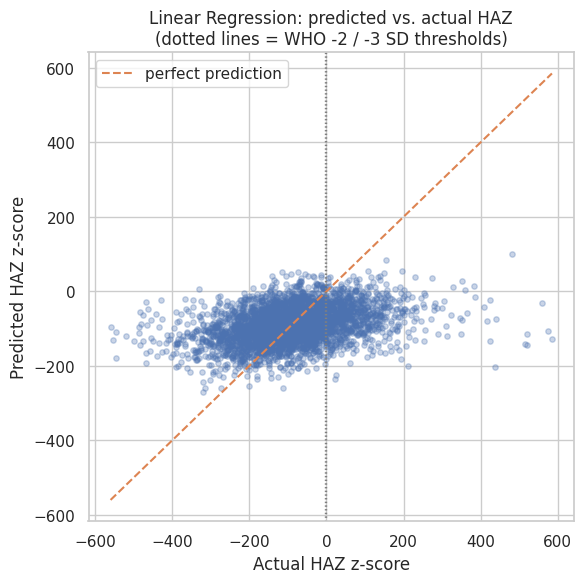

In [20]:

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_reg_test, y_reg_pred, alpha=0.3, s=15, color="#4C72B0")
lims = [min(y_reg_test.min(), y_reg_pred.min()), max(y_reg_test.max(), y_reg_pred.max())]
ax.plot(lims, lims, color="#DD8452", linestyle="--", label="perfect prediction")
ax.axvline(-2, color="grey", linestyle=":", linewidth=1)
ax.axvline(-3, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel("Actual HAZ z-score")
ax.set_ylabel("Predicted HAZ z-score")
ax.set_title(f"{best_reg_name}: predicted vs. actual HAZ\n(dotted lines = WHO -2 / -3 SD thresholds)")
ax.legend()
plt.tight_layout()
plt.show()



**Reading this view:** the scatterplot's dotted lines mark the same -2 SD /
-3 SD WHO thresholds used to build `haz_category` — points that cross those
lines are where a regression error could flip a child's classification bucket
even though the numeric error looks small. This regression view is
diagnostic rather than the model we'd deploy: it tells us how precisely the
predictors track the underlying z-score, but the classification models above
remain primary, since a discrete severity label — not a raw z-score — is
what a health worker acts on.


In [21]:

# --- Bridge to 04_evaluation.ipynb ----------------------------------------
import joblib

bridge_out = {
    "cv_results": cv_results, "pipelines": pipelines, "scoring": scoring,
    "best_model_name": best_model_name, "best_pipeline": best_pipeline,
    "y_pred": y_pred, "y_proba": y_proba,
    "baseline_accuracy": baseline_accuracy, "baseline_precision": baseline_precision,
    "baseline_recall": baseline_recall, "baseline_f1": baseline_f1,
    "baseline_roc_auc": baseline_roc_auc,
}
bridge_path = OUT_DIR / "bridge_03_to_04.joblib"
joblib.dump(bridge_out, bridge_path)
print(f"Saved handoff objects for 04_evaluation.ipynb -> {bridge_path}")


Saved handoff objects for 04_evaluation.ipynb -> /content/drive/MyDrive/Ngao_labs/capstone/child recode/processed/bridge_03_to_04.joblib
